## Машинное обучение 1, ПМИ ФКН ВШЭ

## Практическое задание 1

### О задании

Задание состоит из двух разделов, посвященных работе с табличными данными с помощью библиотеки `polars` и визуализации с помощью `matplotlib`. В первом разделе вам предстоит выполнить базовые задания с помощью вышеуказанных библиотек, а во втором распределить студентов по курсам. Баллы даются за выполнение отдельных пунктов. Задачи в рамках одного раздела рекомендуется решать в том порядке, в котором они даны в задании.

Задание направлено на освоение jupyter notebook (будет использоваться в дальнейших заданиях), библиотек `polars` и `matplotlib`.



## 1. Табличные данные и Polars

Почему polars:
- он написан на Rust, поэтому почти все операции в нём выполняются значительно быстрее, есть распараллеливание из коробки, автоматическая оптимизация запросов и пр
- он позволяет работать с данными, которые не помещаются в оперативку, с этим поможет `pl.LazyFrame` и параметр `engine`/`streaming`
- конечно же имеются дополнительные функции, которых в `pandas` нет, но очень хочется, например агрегации с расширяющимся окном, произвольные оконные функции и прочее, для этого есть крайне гибкая штука `pl.Expr`

Подробнее можете прочитать на [любом](https://habr.com/ru/articles/710240/) [ресурсе](https://realpython.com/polars-python/), [посвящённом](https://blog.jetbrains.com/pycharm/2024/07/polars-vs-pandas/) [`polars`](https://habr.com/ru/companies/spectr/articles/738766/)


Материалы:
1. [Getting started](https://docs.pola.rs/user-guide/getting-started/#reading-writing) из официального руководства
2. [Документация](https://docs.pola.rs/api/python/stable/reference/index.html) со всем необходимым
3. [Модификация для Data Science](https://polars-ds-extension.readthedocs.io/en/latest/index.html), вам скорее всего не понадобится в данном задании, но имейте в виду


In [2]:
# поларс относительно молодой, имейте в виду, что что-то может сломаться, если будете менять версию
!pip install -qU hvplot xlsx2csv polars

In [3]:
import polars as pl
import gc

Скачаем данные:

In [4]:
!wget  -O 'end_seminar.xlsx' -q 'https://www.dropbox.com/scl/fi/2ezfw6b3y1umremflbgdl/end_seminar.xlsx?rlkey=xzecol82ybnpu0eon0b1s11pp&st=f45sugvp&dl=0'

Для пользователей Windows: скачайте файл самостоятельно и поместите его в папку с тетрадкой. Или попробуйте один из следующих вариантов:

In [6]:
# !powershell iwr -outf somefile https://somesite/somefile

In [7]:
# !pip install wget
# import wget
# wget.download('https://www.dropbox.com/scl/fi/2ezfw6b3y1umremflbgdl/end_seminar.xlsx?rlkey=xzecol82ybnpu0eon0b1s11pp&st=f45sugvp&dl=0', 'end_seminar.xlsx')

In [21]:
# читаем датафрейм
initial_df = pl.read_excel("end_seminar.xlsx", engine="xlsx2csv")
print(initial_df.shape[0], "rows")
print(initial_df.estimated_size("mb"), "mb")

429 rows
0.18345928192138672 mb


Как видим, он достаточно маленький. С такими объёмами выбор библиотеки это чисто вкусовщина. Давайте немного поднимем ставки

In [22]:
def repeat_df(df: pl.DataFrame | pl.LazyFrame, n: int = 2) -> pl.LazyFrame:
    return (
        df.lazy()
        .select(pl.col("timestamp").unique().sort().repeat_by(n).flatten())
        .join(df.lazy(), on="timestamp", how="left")
    )

Для работы с датафреймами, которые в память не влезают, нам понадобится объект `pl.LazyFrame`. Он представляет из себя схему выполнения вашего запроса, который оптимизируется, бьётся на батчи и параллелится под капотом через StreamingAPI, что для нас просто идеально. Перевести объект туда можно через метод `lazy`, обратно через `collect`. Учтите, что `streaming=True` работает не со всеми операциями, применяйте с умом, это можно проверить через `pl.LazyFrame.explain(streaming=True)`

In [23]:
repeat_n = 2

repeated_df = repeat_df(initial_df, repeat_n)
print("Schema")
print(repeated_df.explain(streaming=True, optimized=True))

Schema
LEFT JOIN:
LEFT PLAN ON: [col("timestamp")]
  SELECT [col("timestamp").unique().sort(asc).repeat_by([dyn int: 2]).explode()]
    DF ["timestamp", "id", "rating", "group_22", ...]; PROJECT["timestamp"] 1/16 COLUMNS
RIGHT PLAN ON: [col("timestamp")]
  DF ["timestamp", "id", "rating", "group_22", ...]; PROJECT["timestamp", "id", "rating", "group_22", ...] 16/16 COLUMNS
END LEFT JOIN


/tmp/ipython-input-2548353322.py:4: DeprecationWarning: `Expr.flatten()` is deprecated and will be removed in version 2.0. Use `Expr.list.explode(keep_nulls=False, empty_as_null=False)` instead.
  .select(pl.col("timestamp").unique().sort().repeat_by(n).flatten())
/tmp/ipython-input-2973500786.py:5: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  print(repeated_df.explain(streaming=True, optimized=True))


In [24]:
# как видим, повторы работают
repeated_df = repeated_df.collect()
assert repeated_df.shape[0] == initial_df.shape[0] * repeat_n
print(repeated_df.shape[0], "rows")
print(repeated_df.estimated_size("mb"), "mb")

858 rows
0.3668785095214844 mb


Теперь ещё интереснее. Если бы наш датасет был не в 2 раза больше, а в 100000 раз, что бы мы делали? К счастью для нас, поларс может уместить 300кк строк всего лишь в 512Мб, и это даже не прикол, но работать с этим придётся немного иначе

In [25]:
N = 80000

df = repeat_df(initial_df, N)
print(initial_df.estimated_size("gb") * N, "gb")

14.332756400108337 gb


/tmp/ipython-input-2548353322.py:4: DeprecationWarning: `Expr.flatten()` is deprecated and will be removed in version 2.0. Use `Expr.list.explode(keep_nulls=False, empty_as_null=False)` instead.
  .select(pl.col("timestamp").unique().sort().repeat_by(n).flatten())


In [26]:
try:
    print(df.shape[0], "rows")
except AttributeError:
    print("ой, не получилось...")

# df.collect().shape[0] # тоже можно, если влезет
# len(df.collect().to_pandas()) # а такое может крашнуть ядро, попробуйте, хехе...

ой, не получилось...


In [27]:
def lazy_len(df: pl.LazyFrame) -> int:
    return df.select(pl.len()).collect().item()


rows = lazy_len(df)  # намного экономнее, потому что оптимизировано под капотом
assert rows == initial_df.shape[0] * N
print(rows, "rows")

34320000 rows


Далее нужно работать с увеличенным датафреймом `df`

#### 1. [0.5 баллов] Выведите 3 последних строки

Посмотрите на данные и скажите, что они из себя представляют, сколько в таблице строк, какие столбцы? (на это не надо отвечать, просто подумайте об этом)

In [12]:
df.tail(3).collect()

timestamp,id,rating,group_22,is_mi,fall_1,fall_2,fall_3,spring_1,spring_2,spring_3,is_first_time,percentile,group_21,blended,is_ml_student
str,str,i64,i64,i64,str,str,str,str,str,str,str,f64,str,str,bool
"""2024-08-23 16:40:22""","""f5de8b91d28d8d19bf721b14fce501…",1504,null,null,"""Операционные системы 2""","""Безопасность компьютерных сист…","""Основы разработки компьютерных…","""Промышленное программирование …","""Децентрализованные системы""","""Теория и практика онлайн-экспе…","""Да""",0.006289,"""215""","""Введение в дифференциальную ге…",null
"""2024-08-23 16:40:22""","""f5de8b91d28d8d19bf721b14fce501…",1504,null,null,"""Операционные системы 2""","""Безопасность компьютерных сист…","""Основы разработки компьютерных…","""Промышленное программирование …","""Децентрализованные системы""","""Теория и практика онлайн-экспе…","""Да""",0.006289,"""215""","""Введение в дифференциальную ге…",null
"""2024-08-23 16:40:22""","""f5de8b91d28d8d19bf721b14fce501…",1504,null,null,"""Операционные системы 2""","""Безопасность компьютерных сист…","""Основы разработки компьютерных…","""Промышленное программирование …","""Децентрализованные системы""","""Теория и практика онлайн-экспе…","""Да""",0.006289,"""215""","""Введение в дифференциальную ге…",null


### Ответьте на вопросы:
1. Сколько было уникальных пользователей из групп 22-го года набора, а сколько из групп 21-го года?

In [13]:
res = df.select([
    pl.col("id").filter(pl.col("group_22").is_not_null()).n_unique().alias("students_22"),
    pl.col("id").filter(pl.col("group_21").is_not_null()).n_unique().alias("students_21")
]).collect()
print(res)

shape: (1, 2)
┌─────────────┬─────────────┐
│ students_22 ┆ students_21 │
│ ---         ┆ ---         │
│ u32         ┆ u32         │
╞═════════════╪═════════════╡
│ 259         ┆ 159         │
└─────────────┴─────────────┘


уникальных студентов 22 года: 259
уникальных студентов 21 года: 159

2. Есть ли среди объединенного множества 3-го и 4-го курса уникальные студенты с равными перцентилями?

In [14]:
res = df.select([
    (pl.col("id").n_unique() > pl.col("percentile").n_unique()).alias("equal_percentiles")
]).collect()
print(res)

shape: (1, 1)
┌───────────────────┐
│ equal_percentiles │
│ ---               │
│ bool              │
╞═══════════════════╡
│ true              │
└───────────────────┘


да, есть, уникальных айдишников больше чем уникальных перцентилей => есть повторяющиеся перцентили среди уникальных студентов => есть уникальные студенты с равными перцентилями

#### 2. [0.5 балла] Есть ли в данных пропуски? В каких колонках? Сколько их в каждой из этих колонок?

Уникальных или нет - не столь важно

In [15]:
gc.collect()
res = df.select(pl.all().null_count()).collect(streaming=True)
with pl.Config(tbl_cols=-1):  #-> вот тут я использовал гемини чтобы сделать вывод всех колонок для ответа
    print(res)


/tmp/ipython-input-2878642689.py:2: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  res = df.select(pl.all().null_count()).collect(streaming=True)


shape: (1, 16)
┌─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬─────┬────────┐
│ tim ┆ id  ┆ rat ┆ gro ┆ is_ ┆ fal ┆ fal ┆ fal ┆ spr ┆ spr ┆ spr ┆ is_ ┆ per ┆ gro ┆ ble ┆ is_ml_ │
│ est ┆ --- ┆ ing ┆ up_ ┆ mi  ┆ l_1 ┆ l_2 ┆ l_3 ┆ ing ┆ ing ┆ ing ┆ fir ┆ cen ┆ up_ ┆ nde ┆ studen │
│ amp ┆ u32 ┆ --- ┆ 22  ┆ --- ┆ --- ┆ --- ┆ --- ┆ _1  ┆ _2  ┆ _3  ┆ st_ ┆ til ┆ 21  ┆ d   ┆ t      │
│ --- ┆     ┆ u32 ┆ --- ┆ u32 ┆ u32 ┆ u32 ┆ u32 ┆ --- ┆ --- ┆ --- ┆ tim ┆ e   ┆ --- ┆ --- ┆ ---    │
│ u32 ┆     ┆     ┆ u32 ┆     ┆     ┆     ┆     ┆ u32 ┆ u32 ┆ u32 ┆ e   ┆ --- ┆ u32 ┆ u32 ┆ u32    │
│     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆ --- ┆ u32 ┆     ┆     ┆        │
│     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆     ┆ u32 ┆     ┆     ┆     ┆        │
╞═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪═════╪════════╡
│ 0   ┆ 0   ┆ 0   ┆ 127 ┆ 322 ┆ 0   ┆ 0   ┆ 0   ┆ 384 ┆ 384 ┆ 384 ┆ 0   ┆ 0 

Рефлексия - я написал промпт "как в поларсе сделать вывод данных по всем колонкам", это был один из самых простых вариантов, тут на ход решения это использование нейронки не повлияло, я просто сделал красивый вывод ответа, чтобы была видна информация по всем колонкам. Если что в таблице все пропуски (в задании указано, что не столь важно уникальны ли они или нет)

🔄 Преобразуйте датасет - заполните пропуски пустой строкой для строковых колонок, нулём для числовых и False для булевых (постарайтесь избежать перечисления названий всех столбцов). Опирайтесь не на смысл столбцов, а на текущий тип данных.

In [28]:
# your code here
import polars.selectors as cs #-> про этот модуль узнал от нейронки
df = df.with_columns([
    cs.string().fill_null(""),
    cs.boolean().fill_null(False),
    cs.numeric().fill_null(0)
])

Рефлексия - я столкнулся с проблемой - строчка pl.col(pl.Numeric).fill_null(0) не работала -> AttributeError: module 'polars' has no attribute 'Numeric', нашел вариант с прописыванием конкретных типов, но подумал, что это не лучший вариант, спросил у нейронки есть ли вариант лучше, она рассказала про этот модуль. Итог - я понял, что pl.Numeric не существует в этой версии polars и использовал другой способ для того, чтобы выбрать все числовые колонки (результат тот же)

#### 3. [0.5 балла] Посмотрите повнимательнее на колонку 'is_first_time'.

Каково процентное соотношение ответов? Сколько из них "Нет"?

In [17]:
res = df.group_by("is_first_time").len().with_columns(
    pl.col("len").alias("count"),
    (pl.col("len") / pl.sum("len") * 100).alias("percent")
).select(pl.exclude("len")).collect(streaming=True)
print(res)

/tmp/ipython-input-1087550133.py:4: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  ).select(pl.exclude("len")).collect(streaming=True)


shape: (2, 3)
┌───────────────┬──────────┬───────────┐
│ is_first_time ┆ count    ┆ percent   │
│ ---           ┆ ---      ┆ ---       │
│ str           ┆ u32      ┆ f64       │
╞═══════════════╪══════════╪═══════════╡
│ Да            ┆ 32560000 ┆ 94.871795 │
│ Нет           ┆ 1760000  ┆ 5.128205  │
└───────────────┴──────────┴───────────┘


Ответ явно виден в таблице из вывода

Посмотрите на колонку `timestamp` - верно ли, что датафрейм отсортирован по ней?

In [18]:
# your code here
ans = (
    df.with_columns(ts = pl.col("timestamp").str.to_datetime(strict=False))
    .select((pl.col("ts") < pl.col("ts").shift(1)).any())
    .collect()
    .item()
)
print("да" if not ans else "нет")


да


🔄 Оставьте только самую позднюю версию обращений студентов, уберите колонку `is_mi` (она нам не пригодится в дальнейшем) и сохраните изменения. Дубли оставлять тоже не нужно

<i>Обращения со значением "Нет" в 'is_first_time' могут быть как повторными, так и первичными, поскольку поле заполняли сами студенты.</i>

In [29]:
# your code here
df = df.filter(pl.col("timestamp").rank("ordinal", descending=True).over("id") == 1).drop("is_mi") #-> использовал нейронку для поиска rank().over()
print(df.collect(streaming=True).shape)
df = df.collect(streaming=True)

/tmp/ipython-input-3415348077.py:3: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  print(df.collect(streaming=True).shape)


(418, 15)


/tmp/ipython-input-3415348077.py:4: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  df = df.collect(streaming=True)


Рефлексия - можно было бы использовать простой код:

In [ ]:
#НЕ ЗАПУСКАТЬ
df = df.unique(subset=["id"], keep="last").drop("is_mi")
print(df.collect(streaming=True).shape)

Но я хотел бы понять что делать если мы бы не знали, что данные искусственно размножены, потому что код с сортировкой через df.sort не работал (падало ОЗУ), поэтому решил поискать другие способы что можно сделать, наткнулся на это решение. Пояснение - .rank("ordinal", descending=True) - присвоение каждой записи ранга (порядкового номера), самая свежая запись получит ранг 1, вторая по свежести ранг 2 и т.д. - .over("id") == 1 - ранжирование отдельно для каждого id и оставляем только те строки, где ранг 1

#### 4. [0.5 балла] Какие  blended-курсы для четверокурсников существуют? На какой blended-курс записалось наибольшее количество студентов?  На каком из blended-курсов наименьший средний перцентиль студентов, подавших заявку (выведите этот курс и количество студентов на нем)?

In [31]:
blended_df = df.filter(pl.col("blended") != "")
unique_courses = blended_df.select(pl.col("blended").unique()).to_series().to_list()
print(unique_courses)

['Продуктовый подход к анализу данных', 'Введение в дифференциальную геометрию', 'ML System Design', 'Соревновательный анализ данных', 'Безопасность систем на базе LLM', 'Протоколы доказательств с нулевым разглашением']


Ответ - в списке из вывода видно

In [32]:
top_course = blended_df.group_by("blended").len().sort("len", descending=True).head(1)
print(top_course)

shape: (1, 2)
┌─────────────────────────────────┬─────┐
│ blended                         ┆ len │
│ ---                             ┆ --- │
│ str                             ┆ u32 │
╞═════════════════════════════════╪═════╡
│ Протоколы доказательств с нуле… ┆ 44  │
└─────────────────────────────────┴─────┘


наибольшее количество студентов записалось на "протоколы доказательств с нулевым разглашением" (44)

In [34]:
# your code here
min_avg_perc = (
    blended_df.group_by("blended")
    .agg([
        pl.col("percentile").mean().alias("mean_perc"),
        pl.len().alias("count")
    ])
    .sort("mean_perc", descending=False)
    .head(1)
)
print(min_avg_perc)

shape: (1, 3)
┌─────────────────────────────────┬───────────┬───────┐
│ blended                         ┆ mean_perc ┆ count │
│ ---                             ┆ ---       ┆ ---   │
│ str                             ┆ f64       ┆ u32   │
╞═════════════════════════════════╪═══════════╪═══════╡
│ Продуктовый подход к анализу д… ┆ 0.39195   ┆ 25    │
└─────────────────────────────────┴───────────┴───────┘


#### 5. [1 балл] Выясните, есть ли студенты с абсолютно одинаковыми предпочтениями по всем курсам.

Для этого сформируйте таблицу, где для каждого возможного набора курсов посчитано количество студентов, выбравших такой набор, и оставьте только строки где это количество больше 1. Формировать варианты, которые не представлены ни одним студентом изначально, не требуется.


В данном случае набор курсов задается упорядоченным множеством ('fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended'). Элемент blended будет нулевым для 3-го курса.

In [38]:
course_cols = ['fall_1', 'fall_2', 'fall_3', 'spring_1', 'spring_2', 'spring_3', 'blended']
ans = (
    df.group_by(course_cols)
    .len()
    .with_columns(pl.col("len").alias("count"))
    .select(pl.exclude("len"))
    .filter(pl.col("count") > 1)
    .sort("count", descending=True)
)
print(ans)

shape: (15, 8)
┌────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬────────────┬───────┐
│ fall_1     ┆ fall_2     ┆ fall_3     ┆ spring_1   ┆ spring_2   ┆ spring_3   ┆ blended    ┆ count │
│ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---        ┆ ---   │
│ str        ┆ str        ┆ str        ┆ str        ┆ str        ┆ str        ┆ str        ┆ u32   │
╞════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪════════════╪═══════╡
│ Системы    ┆ Системы    ┆ Системы    ┆ Компьютерн ┆ Компьютерн ┆ Компьютерн ┆            ┆ 9     │
│ баз данных ┆ баз данных ┆ баз данных ┆ ые сети    ┆ ые сети    ┆ ые сети    ┆            ┆       │
│ Системы    ┆ Разработка ┆ Распределе ┆ Компьютерн ┆ Компьютерн ┆ Компьютерн ┆            ┆ 4     │
│ баз данных ┆ микросерви ┆ нные       ┆ ые сети    ┆ ые сети    ┆ ые сети    ┆            ┆       │
│            ┆ сов на Go  ┆ системы    ┆            ┆            ┆          

#### 6. [0.5 балла] Найдите курсы по выбору, на которые записывались как студенты 22-го года набора, так и студенты 21-го года.

In [44]:
# your code here
def get_courses(df):
  return (
      df.select(pl.concat_list(course_cols).list.explode().alias("course"))
      .filter(pl.col("course") != "")
      .unique()
  )
s22 = get_courses(df.filter(pl.col("group_22") != 0))
s21 = get_courses(df.filter(pl.col("group_21") != ""))
res = s22.join(s21, on="course", how = "inner")
print(res)

shape: (14, 1)
┌─────────────────────────────────┐
│ course                          │
│ ---                             │
│ str                             │
╞═════════════════════════════════╡
│ Стохастический анализ           │
│ Основы тензорных вычислений     │
│ Типы в языках программирования  │
│ Основы разработки компьютерных… │
│ Специальные разделы матричного… │
│ …                               │
│ Основы информационного поиска   │
│ Математические основы нейросет… │
│ Statistical Learning Theory     │
│ Язык программирования Scala     │
│ Операционные системы 2          │
└─────────────────────────────────┘


Методом исключения найдите курсы, которые предлагались только студентам 2-го года и только студентам 21-го года.

In [48]:
# your code here
c_only22 = s22.join(s21, on="course", how="anti")
c_only21 = s21.join(s22, on="course", how="anti")
print("только 22 год")
print(c_only22)
print("\n\n\n")
print("только 21 год")
print(c_only21)

только 22 год
shape: (24, 1)
┌─────────────────────────────────┐
│ course                          │
│ ---                             │
│ str                             │
╞═════════════════════════════════╡
│ Функциональное программировани… │
│ Язык SQL                        │
│ Топологический анализ данных    │
│ Машинное обучение 2             │
│ Прикладная статистика в машинн… │
│ …                               │
│ Разработка микросервисов на Go  │
│ Дополнительные главы машинного… │
│ Комбинаторная оптимизация       │
│ Рекомендательные системы        │
│ Глубинное обучение в естествен… │
└─────────────────────────────────┘




только 21 год
shape: (29, 1)
┌─────────────────────────────────┐
│ course                          │
│ ---                             │
│ str                             │
╞═════════════════════════════════╡
│ Продуктовый подход к анализу д… │
│ Промышленное программирование … │
│ Генеративные модели на основе … │
│ Теория сложных систем           │
│ 

Видите ли вы что-то необычное в получившихся списках? (менять ничего не нужно, просто подумайте)

**Ответ:** в списках есть курсы с похожими названиями, но они для разных курсов, либо программа на них отличается, несмотяр на названия, либо они реально очень похожи. Ещё можно заметить, что больше половины курсов не совпадают у студентов групп 21 и 22 года, значит у студентов хоть года набора и отличаются всего на год, но учебные планы довольно сильно отличаются относительно кпв (другие необычности не заметил)



### Визуализации

При работе с данными часто неудобно делать какие-то выводы, если смотреть на таблицу и числа в частности, поэтому важно уметь визуализировать данные. Здесь будут описаны ключевые правила оформления графиков для **всех** домашних заданий.

У matplotlib, конечно же, есть [документация](https://matplotlib.org/users/index.html) с большим количеством [примеров](https://matplotlib.org/examples/), но для начала достаточно знать про несколько основных типов графиков:
- plot — обычный поточечный график, которым можно изображать кривые или отдельные точки;
- hist — гистограмма, показывающая распределение некоторой величины;
- scatter — график, показывающий взаимосвязь двух величин;
- bar — столбцовый график, показывающий взаимосвязь количественной величины от категориальной.

В этом задании вы попробуете построить один из них. Не забывайте про базовые принципы построения приличных графиков:
- оси должны быть подписаны, причём не слишком мелко;
- у графика должно быть название;
- если изображено несколько графиков, то необходима поясняющая легенда;
- все линии на графиках должны быть чётко видны (нет похожих цветов или цветов, сливающихся с фоном);
- если возможно сделать график интерактивным, это обычно того стоит - помогает решить проблемы с читаемостью;
- если отображена величина, имеющая очевидный диапазон значений (например, проценты могут быть от 0 до 100), то желательно масштабировать ось на весь диапазон значений (исключением является случай, когда вам необходимо показать малое отличие, которое незаметно в таких масштабах);
- сетка на графике помогает оценить значения в точках на глаз, это обычно полезно, поэтому лучше ее отрисовывать;
- если распределение на гистограмме имеет тяжёлые хвосты, лучше использовать логарифмическую шкалу.

Еще одна библиотека для визуализации: [seaborn](https://jakevdp.github.io/PythonDataScienceHandbook/04.14-visualization-with-seaborn.html). Это настройка над matplotlib, иногда удобнее и красивее делать визуализации через неё.

У `polars` уже есть встроенные инструменты для визуализации, в частности интерактивные на базе [hvplot](https://docs.pola.rs/user-guide/misc/visualization/#plotly) и [altair](https://docs.pola.rs/user-guide/misc/visualization). Из её преимуществ - хорошая производительность при работе с большими данными, есть поддержка самых популярных видов графиков, но синтаксис не самый удобный

#### 7. [0.5 балла] Постройте график (barplot) медианных перцентилей в зависимости от первого символа hex-кода id студента

Таким образом мы на глаз прикидываем, есть ли зависимость между, якобы, случайным id и значимым параметром. Если зависимость есть, и в дальнейшем мы будем сплитовать данные на тест и трейн по такому айдишнику без перемешивания, то можем допустить утечку, поэтому такие особенности важно отслеживать.

В графике явно задайте порядок столбцов по символам hex-алфавита (от 0 до f слева направо) и настройте отображение доверительных интервалов уровня **0.96**. Можно ли говорить о наличии проверяемой зависимости на основе визуальной информации?

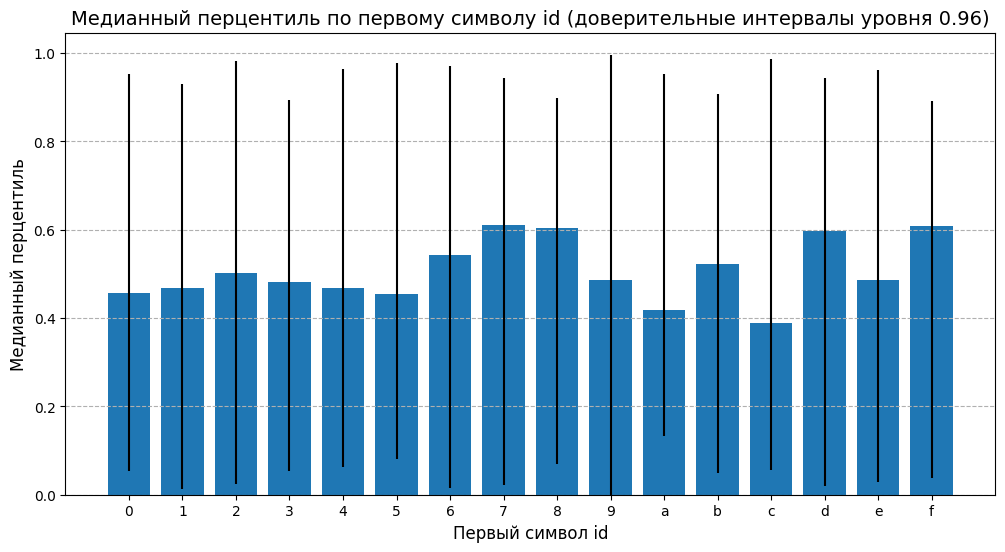

In [65]:
# your code here
import matplotlib.pyplot as plt
plot_data = (
    df.with_columns(
        pl.col("id").str.slice(0, 1).alias("char")
    )
    .group_by("char")
    .agg([
        pl.col("percentile").median().alias("median"),
        pl.col("percentile").quantile(0.02).alias("low"),
        pl.col("percentile").quantile(0.98).alias("high")
    ])
    .with_columns([
        (pl.col("median") - pl.col("low")).alias("err_low"),
        (pl.col("high") - pl.col("median")).alias("err_high")
    ])
    .sort("char")
)
chars = plot_data.select(pl.col("char")).to_series().to_list()
medians = plot_data.select(pl.col("median")).to_series().to_list()
err_low = plot_data.select(pl.col("err_low")).to_series().to_list()
err_high = plot_data.select(pl.col("err_high")).to_series().to_list()
err = [err_low, err_high]
plt.figure(figsize=(12, 6))
plt.bar(
    chars,
    medians,
    yerr=err,
)
plt.title("Медианный перцентиль по первому символу id (доверительные интервалы уровня 0.96)", fontsize=14)
plt.xlabel("Первый символ id", fontsize=12)
plt.ylabel("Медианный перцентиль", fontsize=12)
plt.grid(axis='y', linestyle='--')
plt.savefig("median_percentile_comparison.pdf", format="pdf")
plt.show()

Сохраните график в формате pdf (так он останется векторизованным) или html (тогда останется интерактивным)

In [64]:
# your code here
plt.savefig("median_percentile_comparison.pdf", format="pdf")

<Figure size 640x480 with 0 Axes>

## 2. Распределение студентов по курсам. (6 баллов + 1 бонус)

#### **<span style="color:red">‼️ВНИМАТЕЛЬНО ИЗУЧИТЕ ТЕКСТ НИЖЕ‼️</span>.**

<span style="color:orange">Если во время выполнения заданий у вас возникнут вопросы - еще раз перечитайте текст целиком, скорее всего ответы уже содержатся в нем.</span>

Теперь вам нужно распределить студентов по осенним курсам по выбору, учитывая их предпочтения.

##**Алгоритм распределения студентов по курсам**:

1. Для каждой дисциплины формируется список тех, кто указал её первым приоритетом (если студент должен выбрать два курса по выбору, то для него дисциплины, которые он указал первым и вторым приоритетом, рассматриваются как дисциплины первого приоритета). Если желающих больше, чем мест (см ниже), то выбирается топ по перцентилю рейтинга.
2. На дисциплинах, где остались места после первой волны, формируются списки тех, кто выбрал их вторым приоритетом, и места заполняются лучшими по перцентилю рейтинга студентами. После этого проводится такая же процедура для дисциплин третьего приоритета.
3. Если студент не попал на необходимое количество курсов по итогам трёх волн, с ним связывается учебный офис и решает вопрос в индивидуальном порядке.

## ☝️ **Обращаем ваше внимание на следующие детали:**

### Особенности реализации алгоритма:

- Конкурс на каждый курс общий для 3-го (22-й год) и 4-го курса (21-й год), то есть список формируется из студентов обоих курсов.

- По умолчанию на каждой дисциплине по выбору у 3 и 4 курсов может учиться 1 группа (до 30 студентов).
  - Исключения:
    * Количественные финансы - 60
    * Промышленное программирование на Haskell - 60
    * Рекомендательные системы - 60
    * Глубинное обучение в обработке звука - 1000 (да да, не удивляйтесь! раньше и не такое было...)


- По умолчанию студент выбирает один осенний и один весенний курс по выбору, а также четверокурсники выбирают один blended-курс. Студенты групп **21-го года специализации МОП** выбирают по 2 осенних и 2 весенних курса по выбору. <i>Для студентов, которые выбирают 2 курса (например, осенних) первый приоритет — <code>fall_1</code> и <code>fall_2</code>, второй приоритет — <code>fall_3</code>. Такие студенты участвуют только в двух волнах отбора</i>.

- Студенты специализации МОП не могут выбрать весенним курсом по выбору Машинное обучение 2. Если студент специализации МОП выбрал Машинное обучение 2, то его приоритеты сдвигаются.
  - "Сдвиг" = приоритеты 2 и 3 становятся приоритетами 1 и 2, 3-й приоритет остается пустым.
  - Из-за совпадений первого и второго курса по выбору в прочих случаях двигать приоритеты не надо.


- Blended-курсы не трогайте, по ним не надо распределять, на другие курсы они никак не влияют.

- В рамках своего решения вы можете считать, что в процессе распределения не возникнет ситуации, когда на одно место претендуют студенты с одинаковым перцентилем.


### Я МОП и я люблю <s>Я</s>



**Принадлежность к <s> стойлу</s> специализации МОП определяется так:**

- 21-й год (4-й курс):
  * 211, 212, 213 - МОП; остальные - не МОП! 👎

- 22-й год (3-й курс)
  -  Студенты, у которых проставлен флаг в колонке `is_ml_student`.

### Рейтинг и перцентиль

#### Рейтинг

В столбце `'rating'` записана кредитно-рейтинговая сумма студента (грубо говоря, сумма оценок студента по всем его дисциплинам с весами (веса > 1) — чем дольше шла дисциплина, тем больше вес; подробности тут: https://www.hse.ru/studyspravka/rate/).

Чем больше курсов взял студент за период обучения, и чем лучше он их закрыл, тем выше его значение `'rating'`, соответственно, эта метрика возрастает по "качеству" студента.

#### Перцентиль

В столбце `'percentile'` записан перцентиль студента в рамках своего курса своей ОП.

Перцентиль студента X определяется следующим образом: "процент студентов, чьи результаты обучения лучше, чем у студента X". Соответственно, 0% -- лучший студент на потоке, $\to$ 100% -- худший студент на потоке, то есть метрика убывает по "качеству" студента.


Мы распределяем студентов по топу перцентиля, то есть по наименьшему перцентилю.


За прочими подробностями отправляем вас в ноутбук семинара.

### Требования к решению

- Постарайтесь воздержаться от использования циклов там, где это возможно. Допустимо итерироваться по <b>курсам</b>, на которые проводится отбор, и по <b>волнам</b> отбора. <i>Если вы придумаете, как обойтись без цикла по <b>курсам</b>, то можете получить **+1 бонусный балл** к итоговой оценке. <b>Дублирование кода не признается успешным избавлением от циклов</b></i>

- На выходе ожидается файл `res_fall.csv` с результатами распределения на осенние курсы по выбору. Файл должен быть следующего формата:

    * три столбца: ID, course1, course2
    
    * Если студент не попал на курс, но должен был, то вместо названия курса в ячейке должна быть строка "???"
    
    * Если студент должен выбрать только один курс, то в колонке course2 для него должна стоять строка "-"

    * Если студент должен выбрать два курса по выбору, то порядок в колонках course1 и course2 не важен.
    
    * Формат csv: для сохранения воспользуйтесь `df.to_csv('solution.csv', index=None)`

Для работы вам могут понадобиться следующие данные:

- Результаты опроса (вы уже использовали этот файл в первой части задания, но на всякий случай ссылка: https://www.dropbox.com/scl/fi/2ezfw6b3y1umremflbgdl/end_seminar.xlsx?rlkey=xzecol82ybnpu0eon0b1s11pp&st=f45sugvp&dl=0)


Кстати, убедитесь, что в данных больше нет пропусков, повторных записей и лишних колонок

#### 0. Проверка

Для начала давайте убедимся, что вы успешно выполнили задания первой части и проверим ваши данные на наличие пропусков и повторов

In [66]:
assert type(df) != pl.LazyFrame and type(df) == pl.DataFrame, "Датафрейм не собран"
assert df.shape == (418, 15), "В таблице остались повторы или потеряны данные"
assert df.null_count().sum_horizontal().item() == 0, "В таблице остались пропуски"

Если вы не получили `AssertionError`, то можете продолжать.

#### 1. [1 балл] Создайте новый признак, обозначающий, сколько осенних курсов должен выбрать студент

В этом вам может помочь информация о специализации и группе студента.

In [72]:
# (￣^￣)ゞ
mop_groups_21 = ["211", "212", "213"]
df = df.with_columns(pl.when((pl.col("group_21") != "") & (pl.col("group_21").is_in(mop_groups_21))).then(2).otherwise(1).alias("autumn_courses_needed"))

Проверка:

In [73]:
col_name = "autumn_courses_needed" # insert your new column name as str

ids = [
    "bcca318e644999583156ff3ab9de3d6bd02295dcb166e39006568ffe9582207b",
    "edb64996c64421378537d941a77426a5a7bd84f9967ad9f523ca61386e5469ed",
    "5f96908e3ce5d84d693ddd79670d60cd1c6a02646aa779f46586a7699dda7c25",
    "0f137538a170b64258c0e10839cadc325e5f22fc5bb5fa9e20b7351f0a680366",
]
assert (
    df.filter(pl.col("id").is_in(ids)).sort("id")[col_name] == [2, 1, 1, 1]
).all()

#### 2. [2 балла] Распределите студентов в соответствии с первым приоритетом

In [94]:
bid1 = df.select([
    pl.col("id").alias("ID"),
    pl.col("percentile"),
    pl.col("fall_1").alias("course_name")
])
bid2 = df.filter(pl.col("autumn_courses_needed") == 2).select([
    pl.col("id").alias("ID"),
    pl.col("percentile"),
    pl.col("fall_2").alias("course_name")
])
all_bids = pl.concat([bid1, bid2]).filter(
    (pl.col("course_name") != "")
)
all_bids_unique = all_bids.unique(subset=["ID", "course_name"])
all_bids_unique = all_bids_unique.with_columns(
    pl.when(pl.col("course_name") == "Глубинное обучение в обработке звука").then(1000)
    .when(pl.col("course_name").is_in([
        "Количественные финансы",
        "Промышленное программирование на Haskell",
        "Рекомендательные системы"
    ]))
    .then(60)
    .otherwise(30)
    .alias("capacity")
)
df_wave_1 = all_bids_unique.filter(
    pl.col("percentile").rank("ordinal").over("course_name") <= pl.col("capacity")
).select(["ID", "course_name"])
wave1_results = (
    df_wave_1
    .group_by("ID")
    .agg(pl.col("course_name").alias("courses"))
)
check_data = (
    df.select(["id", "autumn_courses_needed"])
    .rename({"id": "ID", "autumn_courses_needed": "fall_course_num"})
    .join(wave1_results, on="ID", how="left")
    .with_columns(
        pl.col("courses").list.to_struct(fields=["course1", "course2"])
    )
    .unnest("courses")
    .select(["ID", "course1", "course2", "fall_course_num"])
    .to_pandas()
)
try:
    check_first_wave_assignments(check_data)
    print("Все верно")
except Exception as e:
    print("Ошибка:", e)

Все верно


Сверьте назначенные вами на первой волне курсы с эталоном. Для этого преобразуйте данные о назначенных курсах, приведя их в разрез "по студенту" (подробнее см в докстринге тест-функции), **переведите в pandas.DataFrame** и передайте в функцию 'check_first_wave_assignments'. Если функция не выбросила Exception, то всё хорошо!

**Обратите внимание: здесь обрабатывать детали условия касающиеся ответов `'???'` и `'-'` из требований к решению
обрабатывать не нужно!**

Трансформацию датасета (создание колонок `'course1'` и `'course2'`) советуем выделить в отдельную функцию, поскольку она понадобится вам далее при сдаче результатов в тестирующую систему.

In [83]:
import pandas as pd

!wget  -O 'task_2_check.csv' -q 'https://www.dropbox.com/scl/fi/mxmp3b8ecssaei78sk4sp/task_2_check.csv?rlkey=uccmkaeo0zgv78pp3czs0s122&st=gr7s4m5u&dl=0'

check_df = pd.read_csv('./task_2_check.csv')

Если открытие check_df кинуло Exception, проверьте, что файл лежит в той же директории, из которой запущено ядро (kernel) вашего ноутбука (в его current working directory).

*Стандартно файл должен скачиваться как раз туда, но вдруг у вас что-то пошло не так*

In [93]:
from pandas.testing import assert_frame_equal
from collections import Counter

def check_first_wave_assignments(assignments: pd.DataFrame) -> None:
    """
    assignments - pandas DataFrame с колонками ['ID', 'course1', 'course2', 'fall_course_num']. Одна строка - один студент.
    - 'ID' - id студента (не объект индекса!)
    - 'course1', 'course2' - названия курсов, назначенные студенту в первую волну.
    Если один из курсов не назначен (вне зависимости от того, должен ли был быть назначен), то None.
    - 'fall_course_num' - число осенних курсов, которые должен выбрать студент.
    """

    def course_columns_to_set_column(row: pd.DataFrame):
        result = Counter()

        for column in ['course1', 'course2']:
            if (not pd.isna(row[column]) and row[column] is not None):
                result[row[column]] += 1
        return result

    ANSWER_SOURCE = 'task_2_check.csv'

    ALTERNATIVES = {
        "cdb87f7b15495e514eb481230b44540c6b0cfeb347c991f06b1e361fcdef0c0b": [
            Counter({"Глубинное обучение для текстовых данных", "Байесовские методы в машинном обучении"}),
            Counter({"Глубинное обучение для текстовых данных", }),
        ],
        "6fa015d8846e21f4f79bac013b469a1e6e962fffd6121b4d9bcde3906275293e": [
            Counter({"Statistical Learning Theory", }),
            Counter({"Statistical Learning Theory", "Байесовские методы в машинном обучении"}),
        ]
    }

    answer_df = pd.read_csv(ANSWER_SOURCE)
    assignments = assignments.copy()
    assignments['course_set'] = assignments.apply(course_columns_to_set_column, axis=1)
    answer_df['course_set'] =  answer_df.apply(course_columns_to_set_column, axis=1)

    answer_df_common = answer_df[~answer_df['ID'].isin(ALTERNATIVES.keys())][['ID', 'course_set', 'fall_course_num']]
    assignments_common = assignments[~assignments['ID'].isin(ALTERNATIVES.keys())][['ID', 'course_set', 'fall_course_num']]

    answer_df_common = answer_df_common.set_index('ID').sort_index()
    assignments_common = assignments_common.set_index('ID').sort_index()

    assert_frame_equal(answer_df_common, assignments_common, check_dtype=False, check_names=False)

    for student in ALTERNATIVES:
        assert assignments[assignments['ID'] == student]['course_set'].isin(ALTERNATIVES[student]).iloc[0]
        assert answer_df[answer_df['ID'] == student]['fall_course_num'].iloc[0] == assignments[assignments['ID'] == student]['fall_course_num'].iloc[0]

#### 3. [2 балла] Проведите все три волны отбора студентов на курсы по выбору

In [97]:
# (￣^￣)ゞ
#прошлые шаги не буду сюда вставлять, чтобы не нагромождать, они в прошлых ячейках
#начну со второй волны сразу
assigned_w1_by_student = (
    df_wave_1
    .group_by("ID")
    .agg(pl.count().alias("assigned_w1"))
)
df_after_w1 = (
    df.rename({"id": "ID"})
    .join(assigned_w1_by_student, on="ID", how="left")
    .with_columns(pl.col("assigned_w1").fill_null(0))
    .with_columns((pl.col("autumn_courses_needed") - pl.col("assigned_w1")).alias("remaining_needed"))
)
students_need_after_w1 = df_after_w1.filter(pl.col("remaining_needed") > 0).select("ID")
bid2_single = (
    df.filter(pl.col("autumn_courses_needed") == 1)
    .select([
        pl.col("id").alias("ID"),
        pl.col("percentile"),
        pl.col("fall_2").alias("course_name")
    ])
)
bid2_double = (
    df.filter(pl.col("autumn_courses_needed") == 2)
    .select([
        pl.col("id").alias("ID"),
        pl.col("percentile"),
        pl.col("fall_3").alias("course_name")
    ])
)
bids_wave_2 = pl.concat([bid2_single, bid2_double]).filter((pl.col("course_name") != ""))
bids_wave_2 = bids_wave_2.join(students_need_after_w1, on="ID", how="semi")
bids_wave_2 = bids_wave_2.unique(subset=["ID", "course_name"])
bids_wave_2 = bids_wave_2.join(df_wave_1, on=["ID", "course_name"], how="anti")
bids_wave_2 = bids_wave_2.with_columns(
    pl.when(pl.col("course_name") == "Глубинное обучение в обработке звука").then(1000)
    .when(pl.col("course_name").is_in([
        "Количественные финансы",
        "Промышленное программирование на Haskell",
        "Рекомендательные системы"
    ]))
    .then(60)
    .otherwise(30)
    .alias("capacity")
)
taken_after_w1 = (
    df_wave_1
    .group_by("course_name")
    .agg(pl.count().alias("taken_w1"))
)
bids_wave_2 = (
    bids_wave_2
    .join(taken_after_w1, on="course_name", how="left")
    .with_columns(pl.col("taken_w1").fill_null(0))
    .with_columns(
        (pl.col("capacity") - pl.col("taken_w1")).alias("free_slots")
    )
    .filter(pl.col("free_slots") > 0)
)
df_wave_2 = (
    bids_wave_2
    .with_columns(
        pl.col("percentile")
        .rank("ordinal")
        .over("course_name")
        .alias("place_in_course")
    )
    .filter(pl.col("place_in_course") <= pl.col("free_slots"))
    .select(["ID", "course_name"])
)
assigned_w12 = pl.concat([df_wave_1, df_wave_2])
assigned_w12_by_student = (
    assigned_w12
    .group_by("ID")
    .agg(pl.count().alias("assigned_w12"))
)
df_after_w2 = (
    df
    .rename({"id": "ID"})
    .join(assigned_w12_by_student, on="ID", how="left")
    .with_columns(pl.col("assigned_w12").fill_null(0))
    .with_columns(
        (pl.col("autumn_courses_needed") - pl.col("assigned_w12")).alias("remaining_needed")
    )
)
students_need_after_w2 = (
    df_after_w2
    .filter(pl.col("remaining_needed") > 0)
    .filter(pl.col("autumn_courses_needed") == 1)
    .select("ID")
)
bids_wave_3 = (
    df
    .filter(pl.col("autumn_courses_needed") == 1)
    .select([
        pl.col("id").alias("ID"),
        pl.col("percentile"),
        pl.col("fall_3").alias("course_name")
    ])
    .filter(
        (pl.col("course_name") != "") & (pl.col("course_name").is_not_null())
    )
)
bids_wave_3 = bids_wave_3.join(students_need_after_w2, on="ID", how="semi")
bids_wave_3 = bids_wave_3.unique(subset=["ID", "course_name"])
bids_wave_3 = bids_wave_3.join(assigned_w12, on=["ID", "course_name"], how="anti")
bids_wave_3 = bids_wave_3.with_columns(
    pl.when(pl.col("course_name") == "Глубинное обучение в обработке звука").then(1000)
    .when(pl.col("course_name").is_in([
        "Количественные финансы",
        "Промышленное программирование на Haskell",
        "Рекомендательные системы"
    ]))
    .then(60)
    .otherwise(30)
    .alias("capacity")
)
taken_after_w2 = (
    assigned_w12
    .group_by("course_name")
    .agg(pl.count().alias("taken_w12"))
)
bids_wave_3 = (
    bids_wave_3
    .join(taken_after_w2, on="course_name", how="left")
    .with_columns(pl.col("taken_w12").fill_null(0))
    .with_columns((pl.col("capacity") - pl.col("taken_w12")).alias("free_slots"))
    .filter(pl.col("free_slots") > 0)
)
df_wave_3 = (
    bids_wave_3
    .with_columns(
        pl.col("percentile")
        .rank("ordinal")
        .over("course_name")
        .alias("place_in_course")
    )
    .filter(pl.col("place_in_course") <= pl.col("free_slots"))
    .select(["ID", "course_name"])
)
all_assignments = pl.concat([df_wave_1, df_wave_2, df_wave_3])
final_courses = (
    all_assignments
    .group_by("ID")
    .agg(pl.col("course_name").alias("courses"))
)
res = (
    df.select(["id", "autumn_courses_needed"])
    .rename({"id": "ID"})
    .join(final_courses, on="ID", how="left")
    .with_columns(
        pl.when(pl.col("courses").is_null())
          .then(pl.lit([]))
          .otherwise(pl.col("courses"))
          .alias("courses")
    )
    .with_columns(pl.col("courses").list.to_struct(fields=["c1", "c2"]))
    .unnest("courses")
)
res = res.with_columns(
    (pl.col("c1").is_not_null().cast(pl.Int8) + pl.col("c2").is_not_null().cast(pl.Int8)).alias("assigned_cnt")
)
course1_expr = (
    pl.when(pl.col("assigned_cnt") == 0)
      .then(pl.lit("???"))
      .otherwise(pl.col("c1"))
)
course2_expr = (
    pl.when(pl.col("autumn_courses_needed") == 1)
      .then(pl.lit("-"))
      .otherwise(
          pl.when(pl.col("assigned_cnt") < 2)
            .then(pl.lit("???"))
            .otherwise(pl.col("c2"))
      )
)
res = res.with_columns([
    course1_expr.alias("course1"),
    course2_expr.alias("course2")
])
res_fall = res.select(["ID", "course1", "course2"])
res_fall.write_csv("res_fall.csv")

/tmp/ipython-input-375326101.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("assigned_w1"))
/tmp/ipython-input-375326101.py:50: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("taken_w1"))
/tmp/ipython-input-375326101.py:76: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("assigned_w12"))
/tmp/ipython-input-375326101.py:122: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg(pl.count().alias("taken_w12"))


**Отправьте свой файл res_fall.csv в [Я.контест](https://new.contest.yandex.ru/contests/89154/start) и прикрепите/укажите ниже ваш никнейм и id успешной посылки.**

никнейм: alevdokuchaev@edu.hse.ru

id: 156972697

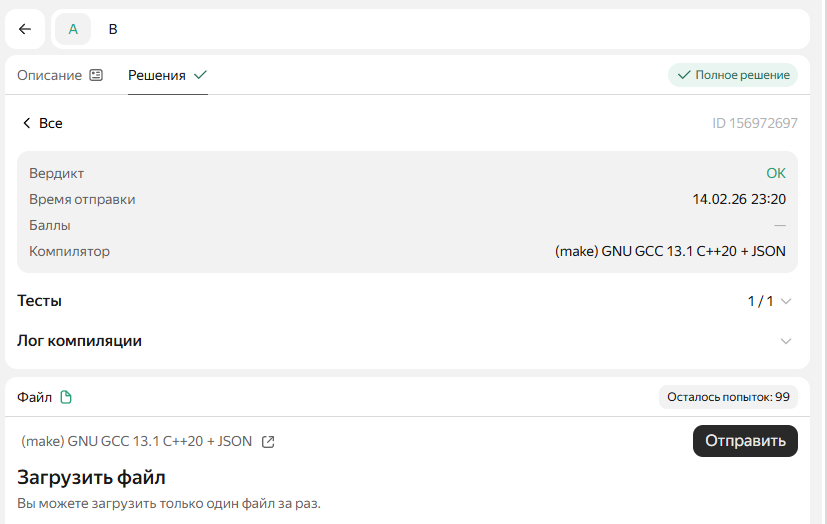

*Дисклеймер:*

Контест выдаётся для самопроверки. Если ваша посылка получила ОК, то код, скорее всего, правильный. Но при этом оценка всё равно может быть снижена в случае обнаружения неэффективностей или ошибок в коде. Если вы сдадите в AnyTask очевидно неработающий код или ноутбук без кода, но при этом в контест будет сдан корректный файл, то это будет расцениваться как плагиат.

На всякий случай просим вас сдать вместе с ноутбуком файл `res_fall.csv` в anytask